In [45]:
import pandas as pd
import re

In [46]:
df = pd.read_csv("crawl_recruitment.careerviet_jobs.csv",keep_default_na=False)

In [47]:
df["title"] = (
    df["title"]
    .astype(str)
    .str.replace(r"\s*\([^)]*\)", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [48]:
df.head(5)

,_id,job_url,benefits[0],benefits[1],benefits[2],benefits[3],benefits[4],benefits[5],benefits[6],benefits[7],...,skills[20],skills[21],skills[22],skills[23],skills[24],skills[25],skills[26],source,title,updated_at
0,694807cfcb490f02d21a3605,https://careerviet.vn/vi/tim-viec-lam/network-...,Laptop,Chế độ bảo hiểm,Du Lịch,Phụ cấp,Đồng phục,Chế độ thưởng,Chăm sóc sức khỏe,Đào tạo,...,,,,,,,,careerviet,Network Engineer - Kỹ Sư Mạng,
1,694807cfcb490f02d21a3606,https://careerviet.vn/vi/tim-viec-lam/quality-...,Laptop,Chế độ bảo hiểm,Phụ cấp,Chế độ thưởng,Đào tạo,Tăng lương,Nghỉ phép năm,,...,,,,,,,,careerviet,Quality Assurance Manager,31/12/2025
2,694807d0cb490f02d21a3607,https://careerviet.vn/vi/tim-viec-lam/threat-a...,Laptop,Chế độ bảo hiểm,Du Lịch,Phụ cấp,Xe đưa đón,Đồng phục,Chế độ thưởng,Chăm sóc sức khỏe,...,,,,,,,,careerviet,Threat and Process Compliance Lead,
3,694807d0cb490f02d21a3608,https://careerviet.vn/vi/tim-viec-lam/sales-le...,Chế độ bảo hiểm,Du Lịch,Phụ cấp,Đồng phục,Chế độ thưởng,Chăm sóc sức khỏe,Đào tạo,Tăng lương,...,,,,,,,,careerviet,Sales Leader B2B/ Trưởng Nhóm Kinh Doanh Phần ...,17/12/2025
4,694807d1cb490f02d21a3609,https://careerviet.vn/vi/tim-viec-lam/chuyen-v...,Laptop,Chế độ bảo hiểm,Phụ cấp,Đồng phục,Công tác phí,Nghỉ phép năm,,,...,,,,,,,,careerviet,Chuyên viên ERP,


In [49]:
USD_TO_VND = 26281
def normalize_vn_number(text: str) -> str:
    text = re.sub(r"(\d),(\d{1,2})(?!\d)", r"\1.\2", text)
    text = text.replace(",", "")
    return text

def parse_salary_to_million(s):
    if pd.isna(s):
        return pd.NA

    s = str(s).strip().lower()

    # Không có số -> drop
    if not re.search(r"\d", s):
        return pd.NA

    s = re.sub(r"(\d),(\d{1,2})(?!\d)", r"\1.\2", s)
    s = s.replace(",", "")

    nums = [float(x) for x in re.findall(r"\d+\.?\d*", s)]
    if not nums:
        return pd.NA

    is_up_to = ("lên đến" in s) or ("up to" in s)
    is_above = ("trên" in s) or ("từ" in s) or ("from" in s) or ("over" in s) or ("above" in s) or (">=" in s) or (">" in s)

    value = nums[0] if (is_up_to or is_above) else max(nums)

    if "usd" in s:
        return round(value * USD_TO_VND / 1_000_000, 2)

    if ("tr" in s) or ("triệu" in s) or ("vnd" in s):
        return round(value, 2)

    return pd.NA


df["salary"] = df["salary"].apply(parse_salary_to_million)
df = df.dropna(subset=["salary"])

In [50]:
df[["salary","title"]].head(10)

,salary,title
0,13.0,Network Engineer - Kỹ Sư Mạng
3,40.0,Sales Leader B2B/ Trưởng Nhóm Kinh Doanh Phần ...
5,39.42,Senior Telecom Operation Specialist
6,52.56,Cloud System Operations
7,35.0,Sr. IT Business Analyst – Software Development
13,30.0,Chuyên viên tư vấn triển khai phần mềm ERP
16,35.0,Sr. IT Business Analyst – Software Development
18,35.0,Chuyên viên Phát Triển Ứng Dụng – Mobile & Web...
20,30.0,Account Manager
21,30.0,Kiểm soát Nội bộ


In [51]:
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Columns: 146 entries, _id to updated_at
dtypes: object(146)
memory usage: 650.3+ KB


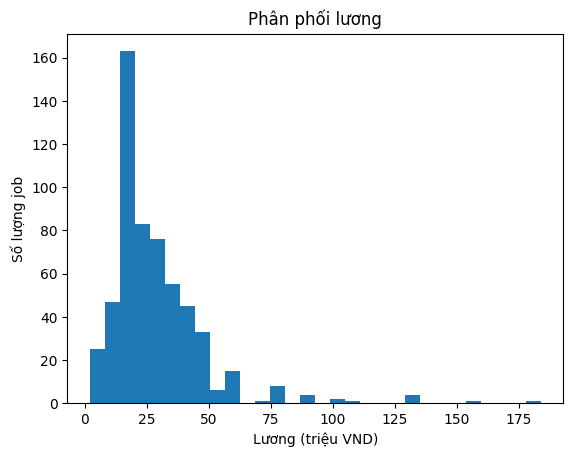

In [52]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df["salary"], bins=30)
plt.xlabel("Lương (triệu VND)")
plt.ylabel("Số lượng job")
plt.title("Phân phối lương")
plt.show()

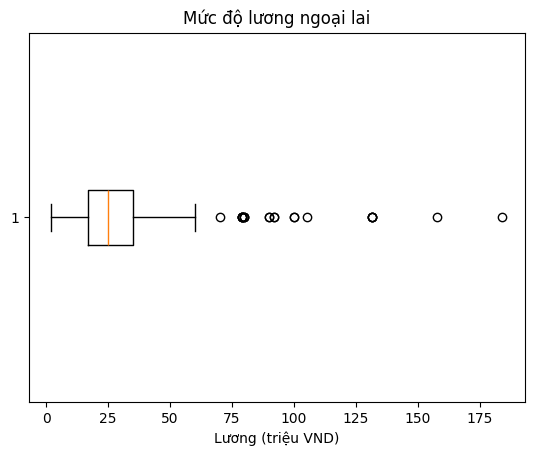

In [55]:
plt.figure()
plt.boxplot(df["salary"], vert=False)
plt.xlabel("Lương (triệu VND)")
plt.title("Mức độ lương ngoại lai")
plt.show()